# What the code does:

1. load the txt files with the raw fluorescence (release) readings into a dataframe (df)
2. process the df and normalize the readings, so the release (CFR) ranges from 0 to 1
3. plot the data for analysis
4. save the main cols -- time, raw fluorescence reading, CFR -- for each file into a summary df, and write it to an excel file

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
#path of directory with the txt files to be processed; each directory corresponds to one batch of liposomes
input_dir_path = r"C:\Users\fal-s\Desktop\Masters thesis notebooks\LBC-L\LBC-L1"
DATA_DIR = Path(input_dir_path)
OUTPUT_FILE = DATA_DIR.name + "-release_summary.xlsx"

In [4]:
def load_data(file, skip_rows = 4):

    """
    reads the raw txt file into a dataframe with two columns: time, intensity
    """

    df = pd.read_csv(
        file,
        skiprows = skip_rows, #based on how the raw data txt file is structured, skip first 4 rows and go straight to the time, flourescence values
        sep=None,
        engine="python", #{sep = None, engine = "python"} is safer when using instrument txt data files as python is tolerant
        header=None,
        names=["time", "intensity"]
    )

    #drop last row as it has the "</Trace>"
    df = df.drop(df.index[-1])

    #set the values to numeric; otherwise they read as strings
    df["time"] = pd.to_numeric(df["time"], errors='coerce')
    df["intensity"] = pd.to_numeric(df["intensity"], errors='coerce')
    
    return df

The dataframe from above, containing the time and raw fluorescence readings, is then passed to the `process_data` function defined below, which processes the raw data into normalized release (CFR).

In [6]:
def process_data(df, bl_time = 60, trtx_time = 30):

    """
    normalizes the data so that the baseline (before any ultrasound) is 0, and the maximum possible release is 1.
    three cols are added to the input df, namely: baseline, trtx, and release% which is the normalized release (CFR).
    """

    # baseline: mean of intensity for first 60 seconds
    bl_rows = df[df["time"] <= bl_time]
    bl = bl_rows["intensity"].mean()

    #trtx: mean of intensity for last 30 seconds
    max_time = df["time"].max()
    trtx_rows = df[df["time"] >= max_time - trtx_time]
    trtx = trtx_rows["intensity"].mean()

    #saving the baseline and trtx to the df
    df["baseline"] = bl
    df["trtx"] = trtx

    # normalization
    df["release%"] = (df["intensity"] - bl)/ (trtx - bl)

    return df, bl, trtx

In [7]:
def plot_data(df, title, bl=60, last_pulse = 270):

    """
    the input df now has 5 cols: time, (raw) intensity, (raw) baseline, (raw) trtx and release% (CFR). 
    this function plots two figures of the df: time vs. fluorescence and time vs. the normalized release (CFR)
    for each plot, a vertical highlights the end of the baseline (assumed to be at 60s by default), and 10 s after the last pulse
    """

    fig, ax = plt.subplots(1,2, figsize=(10,4))

    ax[0].plot(df["time"], df["intensity"])
    ax[0].set_title("Raw Signal: Fluorescence vs. Time")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Fluorescence")
    ax[0].axvline(bl, color='green', alpha=0.5)
    ax[0].axvline(last_pulse, color='green', alpha=0.5)
    
    for x in np.arange(0, 351, 10):
        ax[0].axvline(x=x, color='gray', alpha=0.3)


    ax[1].plot(df["time"], df["release%"])
    ax[1].set_title("CFR vs. Time")
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("CFR")
    ax[1].axvline(bl, color='green', alpha=0.5)
    ax[1].axvline(last_pulse, color='green', alpha=0.5)
    
    for x in np.arange(0, 351, 10):
        ax[1].axvline(x=x, color='gray', alpha=0.3)

    for y in np.arange(0, 1.01, 0.1):
        ax[1].axhline(y=y, color='gray', alpha=0.3)

    fig.suptitle(title)

    plt.tight_layout()
    plt.show()

Processing 20-1


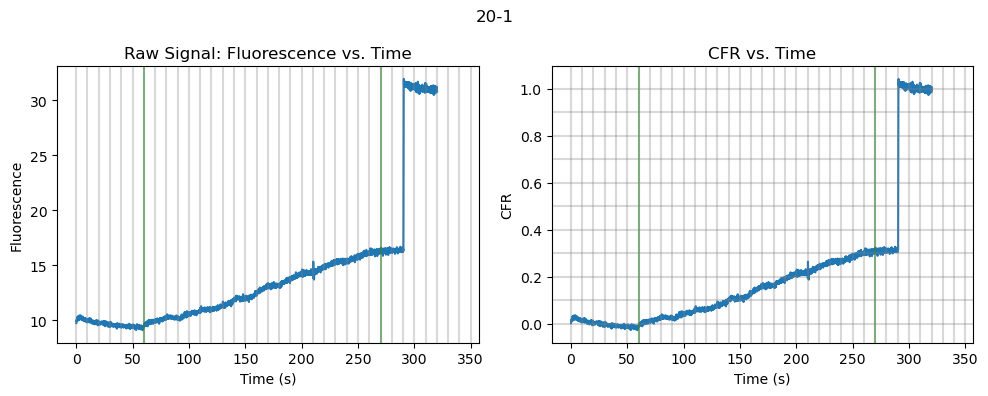

Processing 20-2


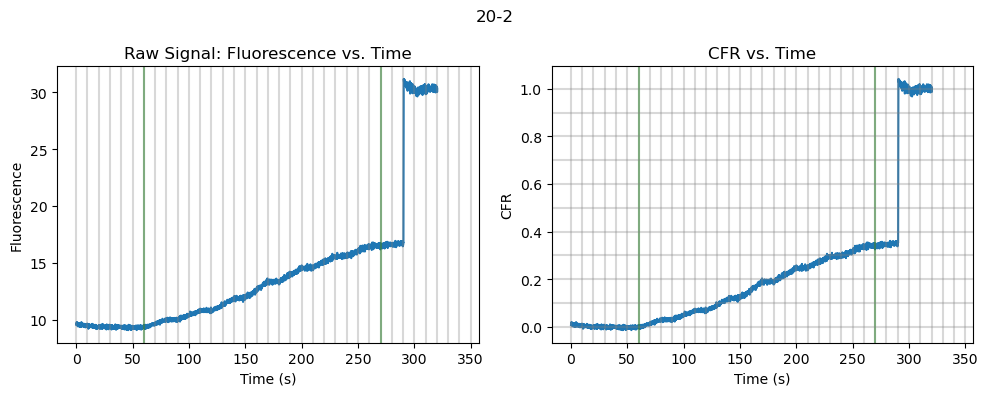

Processing 20-3


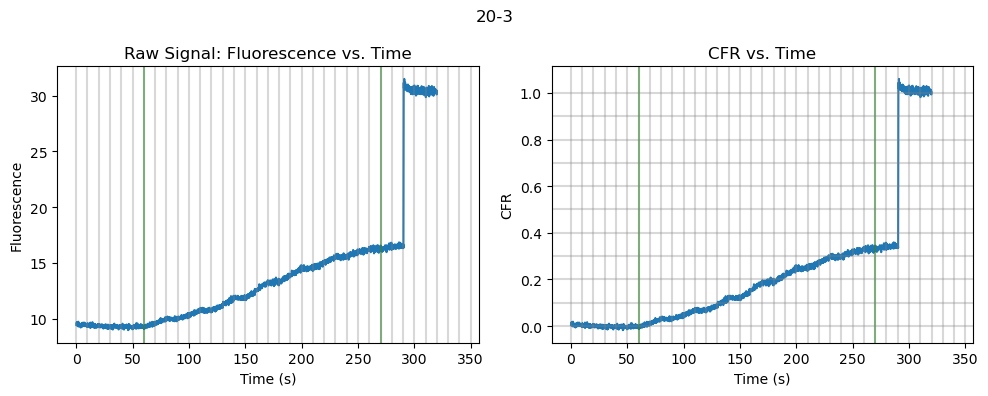

Processing 22-1


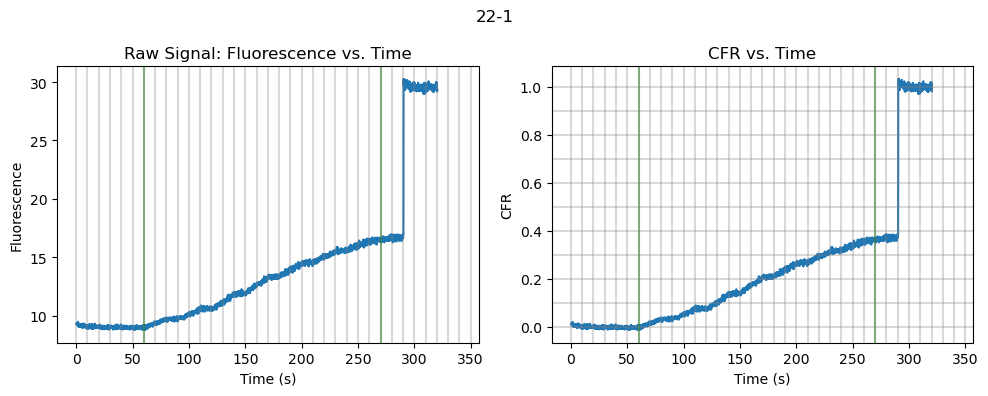

Processing 22-2


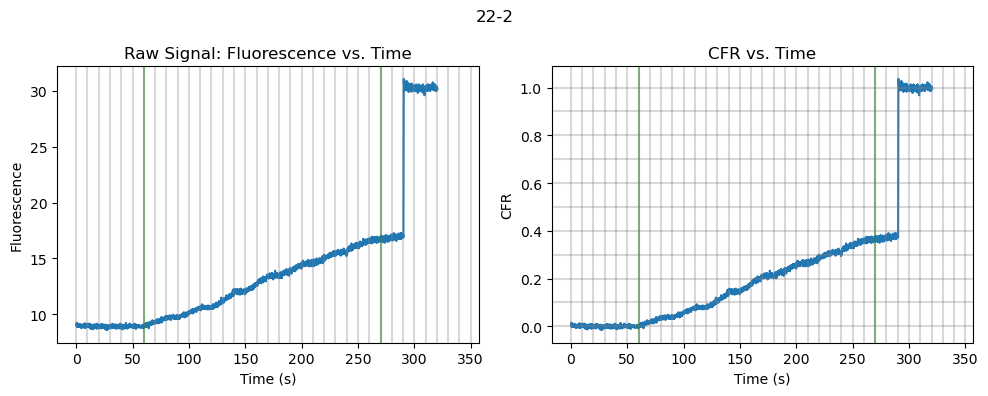

Processing 22-3


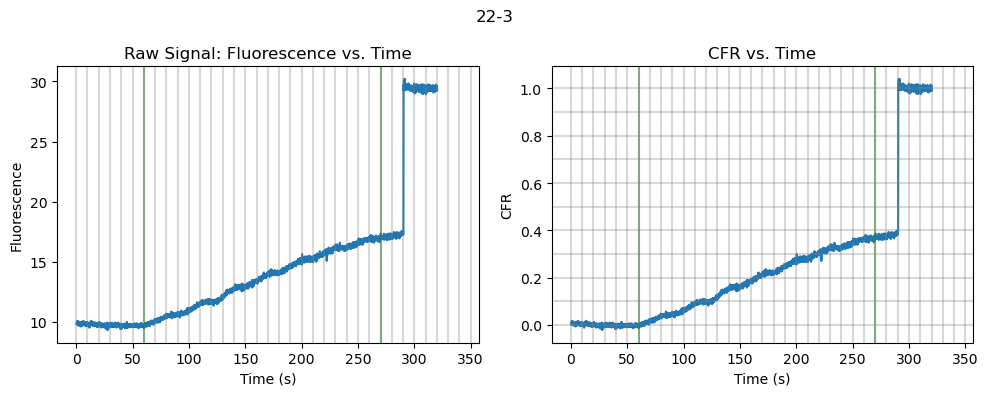

Processing 24-1


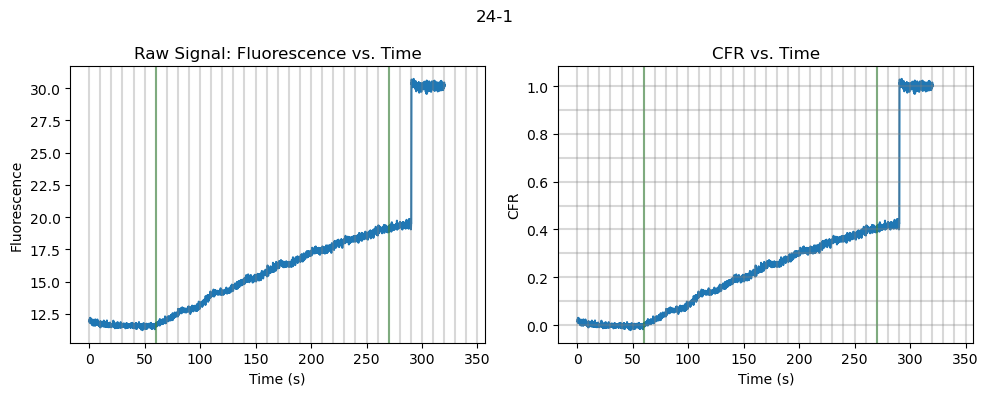

Processing 24-2


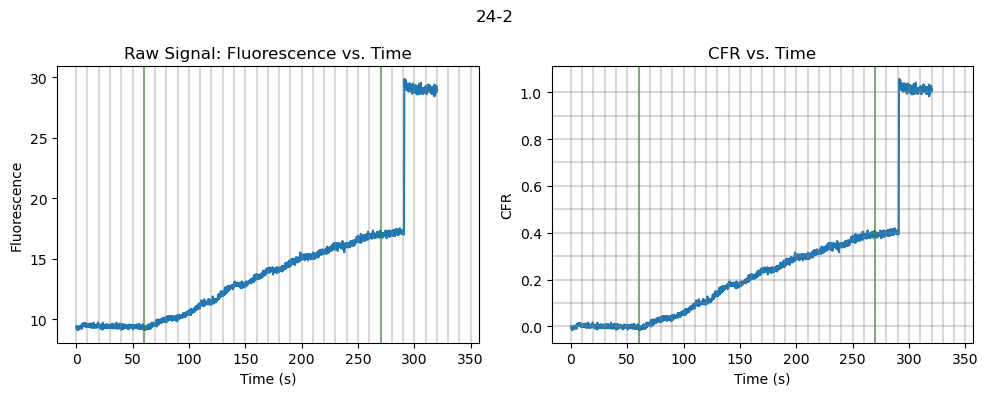

Processing 24-3


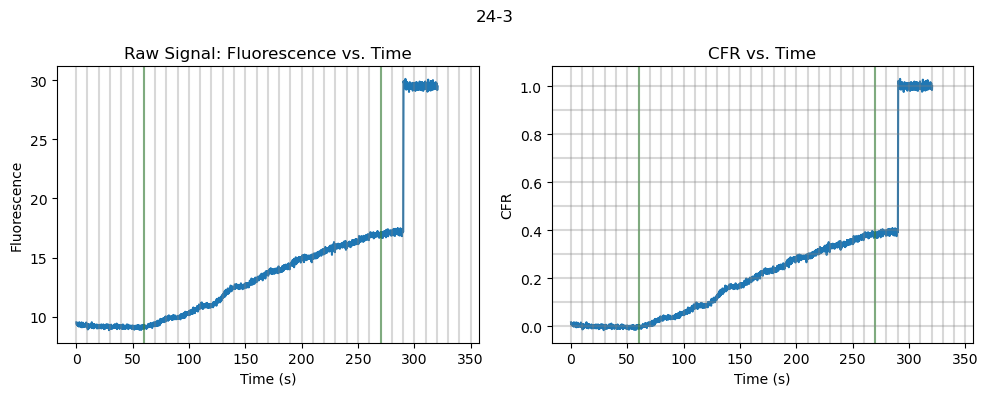

Processing 26-1


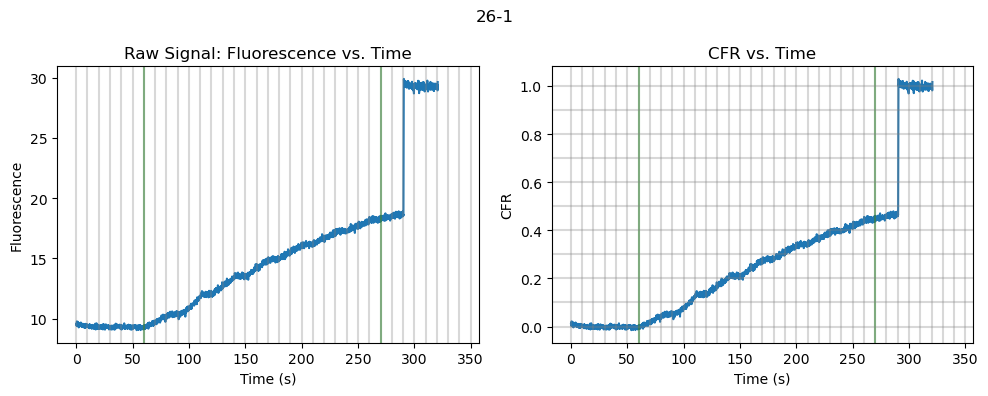

Processing 26-2


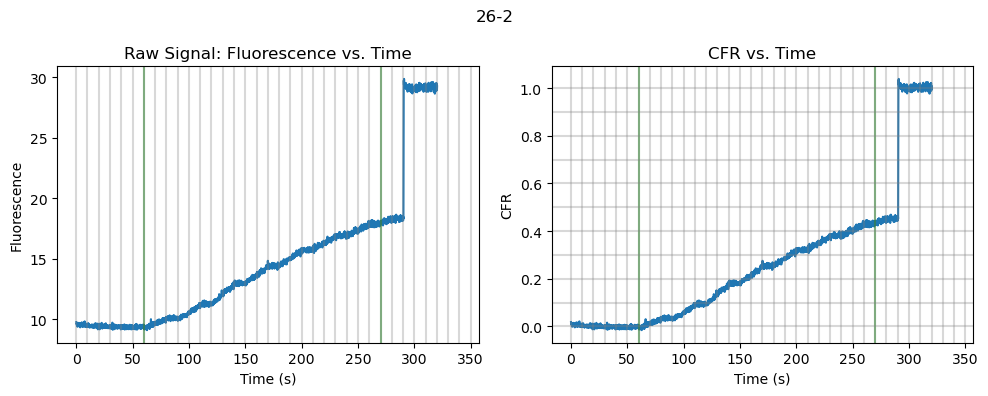

Processing 26-3


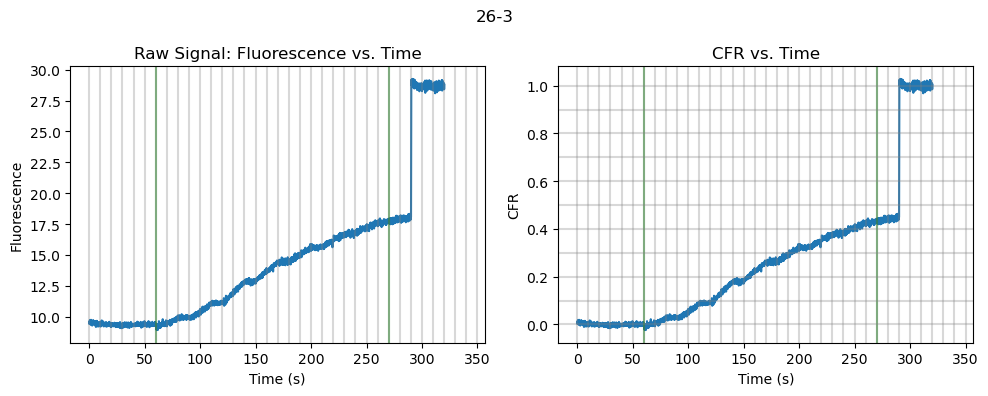

Processing 28-1


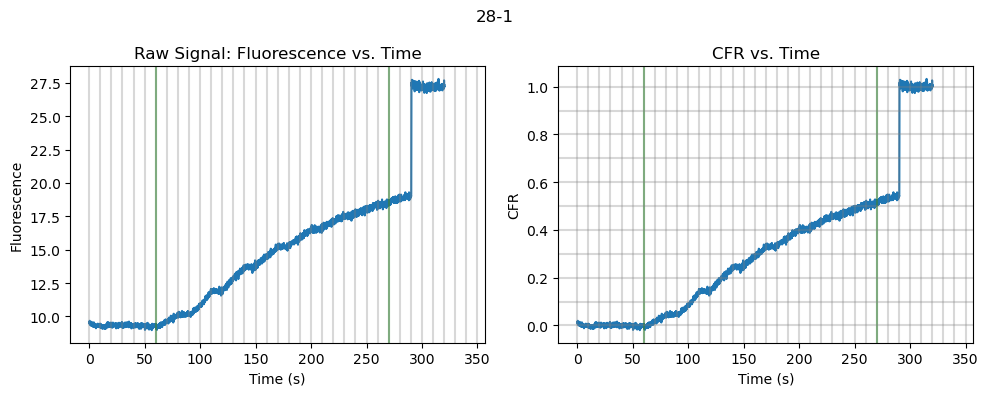

Processing 28-2


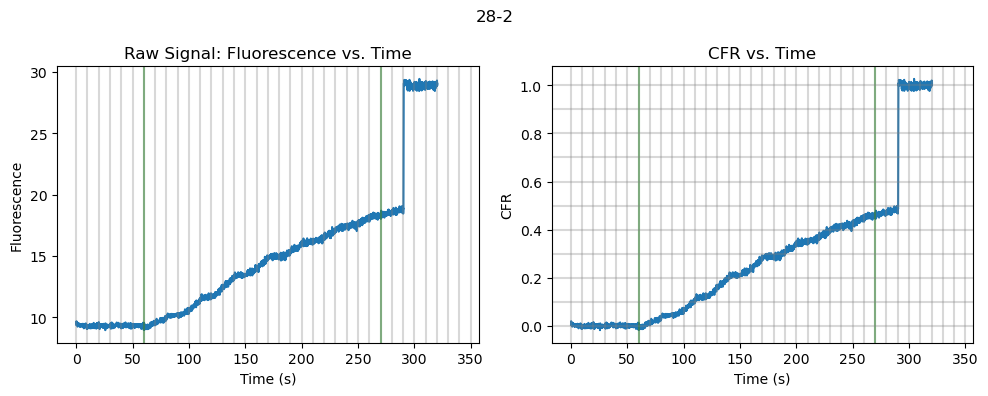

Processing 28-3


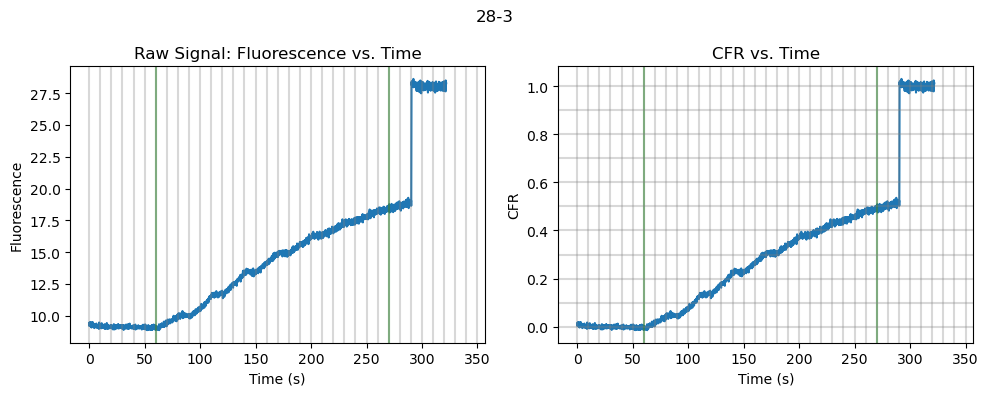

In [8]:
summary_cols = []

with pd.ExcelWriter(OUTPUT_FILE) as writer:
    
    for file in DATA_DIR.glob("*.txt"): #iterate through each txt file in the directory

        name = file.stem #get the filename without the extension
        print(f"Processing {name}")

        # load 
        df = load_data(file)

        # process (get the bl, trtx, normalize the release readings)
        df, bl, trtx = process_data(df)

        # plot the fluorescence vs. time and release vs. time for the file
        plot_data(df, name)

        # save individual sheet
        df.to_excel(writer, sheet_name=name, index=False)

        # make a copy of the main cols for this df, to save to a summary file; each df represents a specific sample ran under a specific set of conditions
        temp = df[["time", "release%", "intensity"]].copy()
        # rename columns to include filename so cols can be traced back to the corresponding sample
        temp.columns = pd.MultiIndex.from_product([[name], ["time", "release%", "intensity"]])

        #save columns of this file to the "summary_file"
        summary_cols.append(temp)

    # combine columns of each file side-by-side, each (time,release) pair of cols will have its filename (e.g. 20-3) on the cell above
    summary_df = pd.concat(summary_cols, axis=1)

    # save summary sheet to same excel
    summary_df.to_excel(writer, sheet_name="summary")

In [9]:
#get the names of all samples in this directory
files=summary_df.columns.get_level_values(0).unique().tolist()
files

['20-1',
 '20-2',
 '20-3',
 '22-1',
 '22-2',
 '22-3',
 '24-1',
 '24-2',
 '24-3',
 '26-1',
 '26-2',
 '26-3',
 '28-1',
 '28-2',
 '28-3']

In [10]:
# group samples by power density
groups = {}

for f in files:
    power = f.split("-")[0]   # extract 20%, 26%, etc
    
    if power not in groups:
        groups[power] = []
        
    groups[power].append(f)

In [11]:
groups.items()

dict_items([('20', ['20-1', '20-2', '20-3']), ('22', ['22-1', '22-2', '22-3']), ('24', ['24-1', '24-2', '24-3']), ('26', ['26-1', '26-2', '26-3']), ('28', ['28-1', '28-2', '28-3'])])

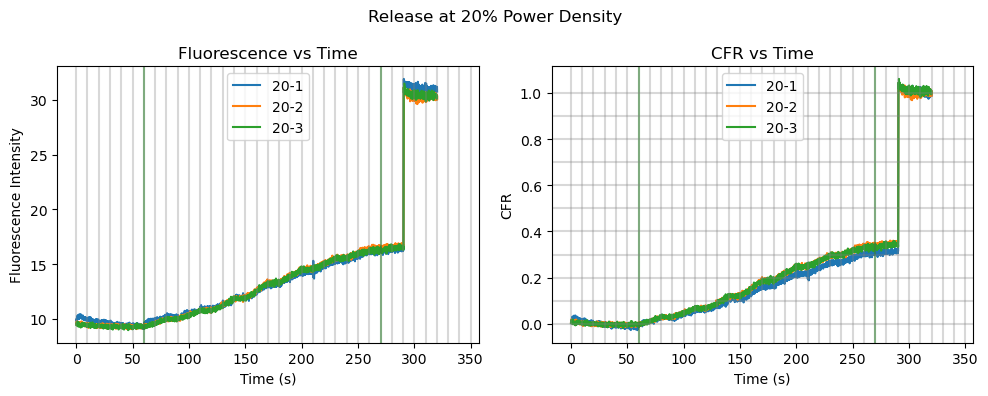

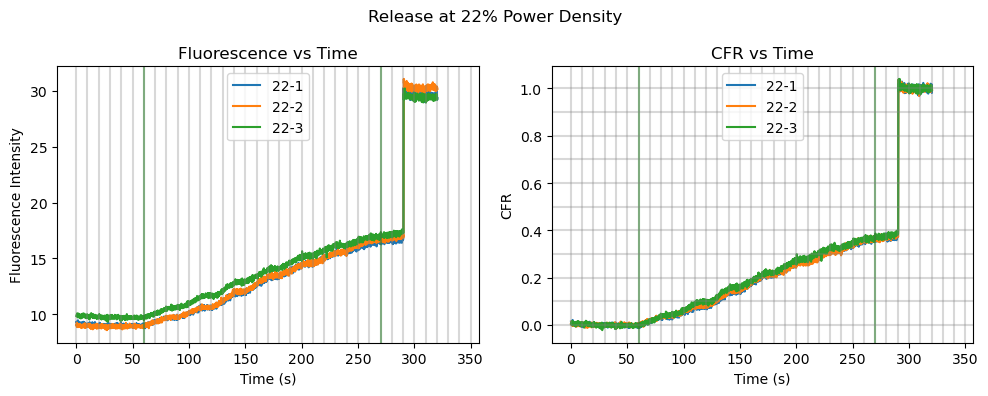

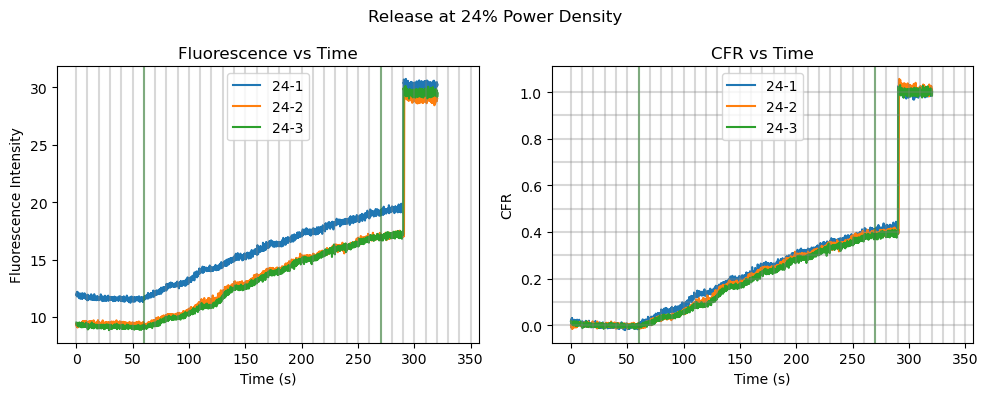

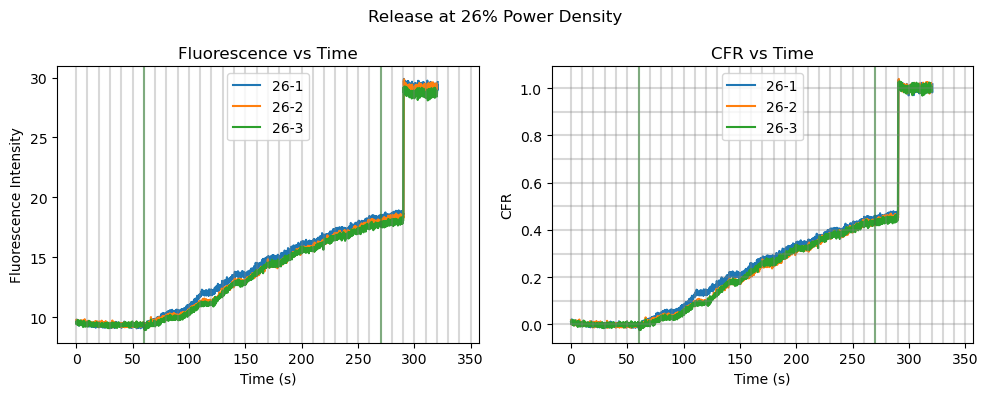

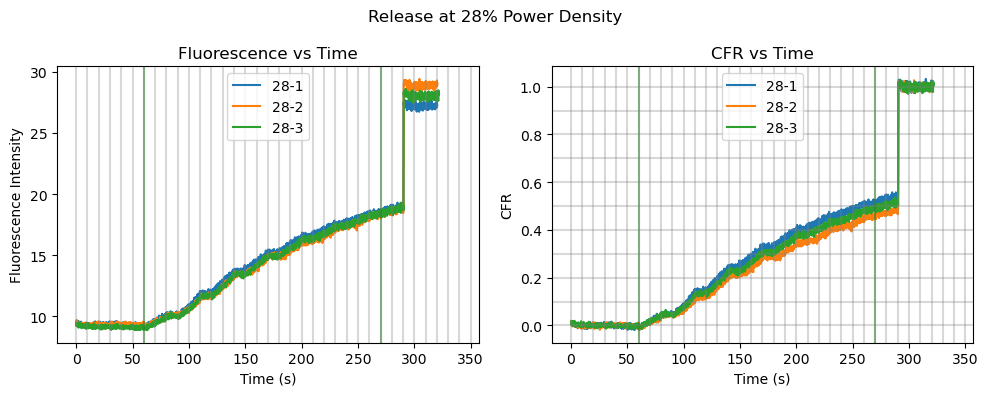

In [12]:
for power, samples in groups.items():
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    
    for sample in samples:
        time = summary_df[(sample, "time")]
        release = summary_df[(sample, "release%")]
        intensity = summary_df[(sample, "intensity")]
        
        axes[0].plot(time, intensity, label=sample)
        axes[1].plot(time, release, label=sample)
        
    axes[0].set_title(f"Fluorescence vs Time")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Fluorescence Intensity")
        
    axes[1].set_title(f"CFR vs Time")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("CFR")
        
    # --- Shared styling ---
    for ax in axes:
        ax.axvline(60, color='green', alpha=0.5)
        ax.axvline(270, color='green', alpha=0.5)
    
        for x in np.arange(0, 351, 10):
            ax.axvline(x=x, color='gray', alpha=0.3)

        ax.legend()
        
    for y in np.arange(0, 1.01, 0.1):
        axes[1].axhline(y=y, color='gray', alpha=0.3)
    
        
    fig.suptitle(f"Release at {power}% Power Density")
    plt.tight_layout()
    plt.show()